# Airline Passenger Satisfaction — YSA

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,roc_auc_score
filterwarnings("ignore")

## 1. Veri Yükleme ve Ön İşleme

In [46]:
train_data=pd.read_csv(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\data\train.csv")
test_data=pd.read_csv(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\data\test.csv")
all_data=pd.concat((train_data.loc[:,"Gender":"satisfaction"],
                    test_data.loc[:,"Gender":"satisfaction"]))

In [47]:
all_data.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [48]:
all_data["Arrival Delay in Minutes"]=all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())

In [49]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non

In [50]:
numeric_cols=all_data.select_dtypes(include=["int64","float64"]).columns
numeric_cols

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

In [51]:
categoric_cols=all_data.select_dtypes(include="object").columns
categoric_cols

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

In [52]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [53]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
all_data["satisfaction"]=label_encoder.fit_transform(all_data["satisfaction"].str.strip())
print(all_data["satisfaction"].unique())
all_data.head()

[0 1]


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [54]:
columns=["Gender","Customer Type","Type of Travel","Class"]
for i in columns:
    all_data[i]=label_encoder.fit_transform(all_data[i].str.strip())
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [55]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()
data_scaled=minmax_scaler.fit_transform(all_data)
data_scaled=pd.DataFrame(data_scaled,columns=all_data.columns)
data_scaled.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1.0,0.0,0.076923,1.0,1.0,0.086632,0.6,0.8,0.6,0.2,...,1.0,0.8,0.6,0.75,0.8,1.0,1.0,0.015704,0.011364,0.0
1,1.0,1.0,0.230769,0.0,0.0,0.041195,0.6,0.4,0.6,0.6,...,0.2,0.2,1.0,0.50,0.2,0.8,0.2,0.000628,0.003788,0.0
2,0.0,0.0,0.243590,0.0,0.0,0.224354,0.4,0.4,0.4,0.4,...,1.0,0.8,0.6,0.75,0.8,0.8,1.0,0.000000,0.000000,1.0
3,0.0,0.0,0.230769,0.0,0.0,0.107229,0.4,1.0,1.0,1.0,...,0.4,0.4,1.0,0.50,0.2,0.8,0.4,0.006910,0.005682,0.0
4,1.0,0.0,0.692308,0.0,0.0,0.036955,0.6,0.6,0.6,0.6,...,0.6,0.6,0.8,0.75,0.6,0.6,0.6,0.000000,0.000000,1.0


In [56]:
X=data_scaled.drop("satisfaction",axis=1)
y=data_scaled["satisfaction"]
feature_names=X.columns

In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## 2. Yapay Sinir Ağları

In [58]:
from keras.models import Sequential
from keras.layers import Dense,Dropout


In [59]:
model=Sequential()

model.add(Dense(64,activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(32,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(1,activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history=model.fit(
    X_train,y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8727 - loss: 0.3092 - val_accuracy: 0.9219 - val_loss: 0.1947
Epoch 2/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 943us/step - accuracy: 0.9182 - loss: 0.2069 - val_accuracy: 0.9400 - val_loss: 0.1554
Epoch 3/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 953us/step - accuracy: 0.9300 - loss: 0.1757 - val_accuracy: 0.9441 - val_loss: 0.1400
Epoch 4/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 925us/step - accuracy: 0.9350 - loss: 0.1609 - val_accuracy: 0.9480 - val_loss: 0.1298
Epoch 5/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.9390 - loss: 0.1506 - val_accuracy: 0.9472 - val_loss: 0.1295
Epoch 6/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 940us/step - accuracy: 0.9405 - loss: 0.1444 - val_accuracy: 0.9509 - val_loss: 0.1198
Epoch 7/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 929us/step - accuracy: 0.9435 - loss: 0.1362 - val_accuracy: 0.9508 - val_loss: 0.1215
Epoch 8/30
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 2s 941us/step - accuracy: 0.9438 - l

In [96]:
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5).astype(int)
print("roc auc score:{0:0.2f}".format(roc_auc_score(y_test,y_pred)))

1218/1218 ━━━━━━━━━━━━━━━━━━━━ 1s 442us/step
roc auc score:0.95


In [97]:
print(model.input_shape)

(None, 22)


In [98]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96     21979
         1.0       0.97      0.92      0.94     16985

    accuracy                           0.95     38964
   macro avg       0.96      0.95      0.95     38964
weighted avg       0.95      0.95      0.95     38964



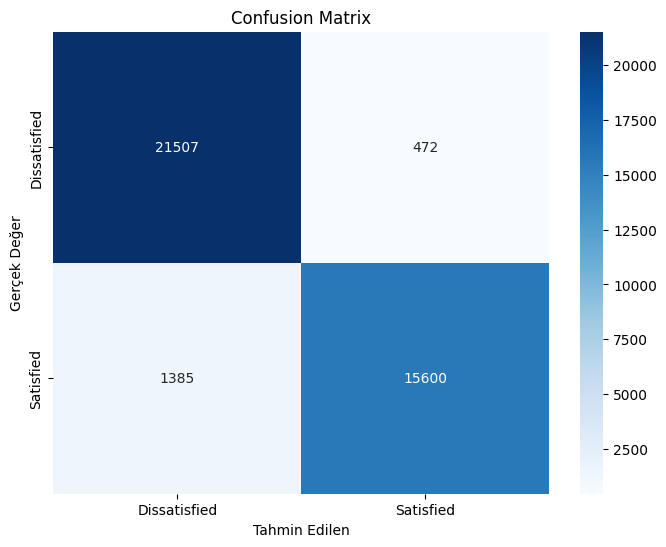

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=["Dissatisfied", "Satisfied"],
            yticklabels=["Dissatisfied", "Satisfied"])

plt.title("Confusion Matrix")
plt.ylabel("Gerçek Değer")
plt.xlabel("Tahmin Edilen")
plt.show()

In [100]:
import pickle

pickle.dump(model, open("model_ysa.pkl", "wb"))